## Population.ipynb
Author Cathal Redmond
# Date 2025-Oct-23


In [143]:
# Import modules we will use for analysis
import pandas as pd
import tabulate
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.transforms as transforms

In [144]:
# import the data from the internet. 
# Define the URL location 
url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/FY006A/CSV/1.0/en" 
#Read the data from the URL and assign it into a dataframe "df"
df = pd.read_csv(url)
# Show some of the data to check its form
df.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


Need to slice the gender from this dataframe 

In [145]:
## Remove Duplicate Data we wont be using from the dataset by selecting where value does not equal what we want to remove. 

# This removes the duplicate listing of combined male and female values
df = df[df["Sex"] != "Both sexes"] 

# This Removes the duplicate listing of whole country summed values. 
df = df[df["Administrative Counties"] != "Ireland"] 

# Check we have the correct output
df.tail(3)


,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


Now we can do code that will prep this data for analysis. We need to take the column names and assign them into a list


In [146]:
#take column names (headers), and assign them to a list
headers = df.columns.tolist()
headers

['STATISTIC',
 'Statistic Label',
 'TLIST(A1)',
 'CensusYear',
 'C02199V02655',
 'Sex',
 'C02076V03371',
 'Single Year of Age',
 'C03789V04537',
 'Administrative Counties',
 'UNIT',
 'VALUE']

get rid of the columns we will not be using 


In [147]:
## Remove the Data & columns we will not be using 
# Define the list of columns to drop
drop_col_list = ['STATISTIC', 'Statistic Label','TLIST(A1)','CensusYear','C02199V02655','C02076V03371','C03789V04537','UNIT']
# Perform the drop function
df.drop(columns=drop_col_list, inplace=True)

# This line removes the row labeled 'all ages', which could not be removed using drop function. 
df = df[df["Single Year of Age"] != "All ages"]
# Change the label type for "under 1 year" from String to int - changing to "0", which allows for inclusion in analysis with other integer labeled rows. 
df['Single Year of Age'] = df['Single Year of Age'].str.replace('Under 1 year', '0')
# Perform same swap out for any other string- type label, assume any rows with a string label are above 100 years. 
df['Single Year of Age'] = df['Single Year of Age'].str.replace('[a-zA-Z  ]', '', regex=True)

# Force the 'single year of age' data to be int64 type. 
df['Single Year of Age']=df['Single Year of Age'].astype('int64')
df['VALUE']=df['VALUE'].astype('int64')
print (df)
# check the type
df.info()

#export full data file to local machine
df.to_csv("All_Rows_By_Single_year_of_birth.csv")

         Sex  Single Year of Age                Administrative Counties  VALUE
3297    Male                   0                  Carlow County Council    346
3298    Male                   0                    Dublin City Council   3188
3299    Male                   0  Dún Laoghaire Rathdown County Council   1269
3300    Male                   0                  Fingal County Council   2059
3301    Male                   0            South Dublin County Council   1855
...      ...                 ...                                    ...    ...
9787  Female                 100               Roscommon County Council      7
9788  Female                 100                   Sligo County Council      9
9789  Female                 100                   Cavan County Council     12
9790  Female                 100                 Donegal County Council     31
9791  Female                 100                Monaghan County Council      7

[6262 rows x 4 columns]
<class 'pandas.core.frame.D

In [148]:
# Add a new column into the dataframe to define a new category for grouping the population, by 5-year band age ranges (for question 3)

df.loc[df['Single Year of Age'].between(0,4), 'age_group'] = '0-4'
df.loc[df['Single Year of Age'].between(5,9), 'age_group'] = '5-9'
df.loc[df['Single Year of Age'].between(10,14), 'age_group'] = '10-14'
df.loc[df['Single Year of Age'].between(15,19), 'age_group'] = '15-19'
df.loc[df['Single Year of Age'].between(20,24), 'age_group'] = '20-24'
df.loc[df['Single Year of Age'].between(25,29), 'age_group'] = '25-29'
df.loc[df['Single Year of Age'].between(30,34), 'age_group'] = '30-34'
df.loc[df['Single Year of Age'].between(35,39), 'age_group'] = '35-39'
df.loc[df['Single Year of Age'].between(40,44), 'age_group'] = '40-44'
df.loc[df['Single Year of Age'].between(45,49), 'age_group'] = '45-49'
df.loc[df['Single Year of Age'].between(50,54), 'age_group'] = '50-54'
df.loc[df['Single Year of Age'].between(55,59), 'age_group'] = '55-59'
df.loc[df['Single Year of Age'].between(60,64), 'age_group'] = '60-64'
df.loc[df['Single Year of Age'].between(65,69), 'age_group'] = '65-69'
df.loc[df['Single Year of Age'].between(70,74), 'age_group'] = '70-74'
df.loc[df['Single Year of Age'].between(75,79), 'age_group'] = '75-79'
df.loc[df['Single Year of Age'].between(80,84), 'age_group'] = '80-84'
df.loc[df['Single Year of Age'].between(85,89), 'age_group'] = '85-89'
df.loc[df['Single Year of Age'].between(90,94), 'age_group'] = '90-94'
df.loc[df['Single Year of Age'].between(95,99), 'age_group'] = '95-99'
df.loc[df['Single Year of Age'].between(100,1000), 'age_group'] = '100+'

# Display the data 
print(df.info())
print(tabulate.tabulate(df,headers='keys',tablefmt='fancy_grid'))

<class 'pandas.core.frame.DataFrame'>
Index: 6262 entries, 3297 to 9791
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Sex                      6262 non-null   object
 1   Single Year of Age       6262 non-null   int64 
 2   Administrative Counties  6262 non-null   object
 3   VALUE                    6262 non-null   int64 
 4   age_group                6262 non-null   object
dtypes: int64(2), object(3)
memory usage: 293.5+ KB
None
╒══════╤════════╤══════════════════════╤═══════════════════════════════════════╤═════════╤═════════════╕
│      │ Sex    │   Single Year of Age │ Administrative Counties               │   VALUE │ age_group   │
╞══════╪════════╪══════════════════════╪═══════════════════════════════════════╪═════════╪═════════════╡
│ 3297 │ Male   │                    0 │ Carlow County Council                 │     346 │ 0-4         │
├──────┼────────┼──────────────────────┼────────

The problem i now have is that i want to subtract the total amount of each gender in each age group in each county.
I need to perform a three-dimensional operation in two-dimensional space, so i need to choose the correct sequence in which to reduce my dimension space. 

In [149]:
df["county_and_age_group"] = df["Administrative Counties"] + [" "] + df["age_group"]
df

,Sex,Single Year of Age,Administrative Counties,VALUE,age_group,county_and_age_group
3297,Male,0,Carlow County Council,346,0-4,Carlow County Council 0-4
3298,Male,0,Dublin City Council,3188,0-4,Dublin City Council 0-4
3299,Male,0,Dún Laoghaire Rathdown County Council,1269,0-4,Dún Laoghaire Rathdown County Council 0-4
3300,Male,0,Fingal County Council,2059,0-4,Fingal County Council 0-4
3301,Male,0,South Dublin County Council,1855,0-4,South Dublin County Council 0-4
...,...,...,...,...,...,...
9787,Female,100,Roscommon County Council,7,100+,Roscommon County Council 100+
9788,Female,100,Sligo County Council,9,100+,Sligo County Council 100+
9789,Female,100,Cavan County Council,12,100+,Cavan County Council 100+
9790,Female,100,Donegal County Council,31,100+,Donegal County Council 100+


In [150]:
# agg function allows for aggregation of data from multiple sources *(multiple listings of Administrative counties for example) into one group for a given static entitity *(each single year of age)
df_anal = pd.pivot_table(df,'VALUE', "Single Year of Age", "Sex", aggfunc='sum') #N.B. Do not disrupt the order of these variables, as they impact how the dataframe is sliced later. 


#Needed to add the Agg function to this to sum the values in each of the entries listed for each county for sex etc. 
#print("\n df_anal: Sum of each sex, grouped by age")
#print (df_anal)
#print(type(df_anal))

#export full df_anal file to local machine
df_anal.to_csv("population_for_analysis.csv")

# Perform agg fucntion for all ages in each county, but retaining gender information. 
df_sexed_data = pd.pivot_table(df,'VALUE', "county_and_age_group", "Sex", aggfunc ='sum')

# Subtract the number of females from males in each "county & age group" group
df_sexed_data['Excess Females at age group'] = df_sexed_data["Female"] - df_sexed_data["Male"]
# Print to display this data
print("\nSum of each sex, Grouped by County")
print(tabulate.tabulate(df_sexed_data, headers = 'keys', tablefmt='fancy_grid'))

#export df_sexed_data file to csv file
df_sexed_data.to_csv("df_sexed_data.csv")




Sum of each sex, Grouped by County
╒═════════════════════════════════════════════╤══════════╤════════╤═══════════════════════════════╕
│ county_and_age_group                        │   Female │   Male │   Excess Females at age group │
╞═════════════════════════════════════════════╪══════════╪════════╪═══════════════════════════════╡
│ Carlow County Council 0-4                   │     1736 │   1800 │                           -64 │
├─────────────────────────────────────────────┼──────────┼────────┼───────────────────────────────┤
│ Carlow County Council 10-14                 │     2287 │   2400 │                          -113 │
├─────────────────────────────────────────────┼──────────┼────────┼───────────────────────────────┤
│ Carlow County Council 100+                  │        3 │      0 │                             3 │
├─────────────────────────────────────────────┼──────────┼────────┼───────────────────────────────┤
│ Carlow County Council 15-19                 │     2114 │   220

## Anwser to question 3: largest sex gap at specific age: Dublin at age 85-89

In [151]:
# Identify which county has the highest excess gender gap at a specific age
#max_difference = df_sexed_data['Excess Females at age group'].max()
#print(max_difference,"\n")

#df_sexed_data.iloc[df_sexed_data['Excess Females at age group'] == max_difference]
max_index_label = df_sexed_data['Excess Females at age group'].idxmax()
max_row_loc = df_sexed_data.loc[max_index_label]
print(max_row_loc)

Sex
Female                         4603
Male                           2558
Excess Females at age group    2045
Name: Dublin City Council 85-89, dtype: int64


# Time for some Descriptive Stats

In [152]:
headers = list(df_anal.columns)
sex = headers[0]
sex 

'Female'

OK now we need to get the Weighted Mean. 
Formula is Weighted mean = Sum(age*population at age)/sum(populations at age)

In [153]:
# Calculate the total number of people in the country 
number_people = df_anal[sex].sum()
number_people
# holy shit its 5.2 million. 

2604590

<Axes: xlabel='Single Year of Age'>

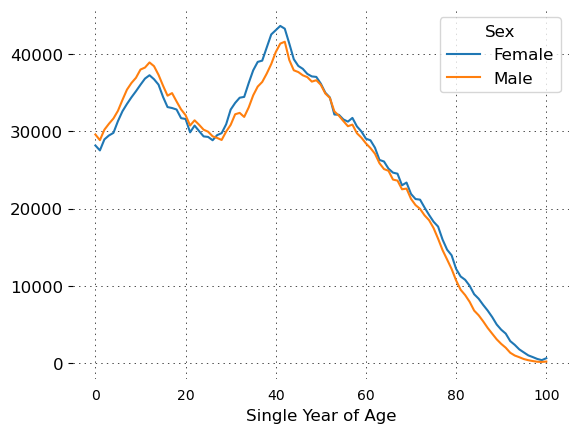

In [154]:
# OK lets see thhis data on a graph
# A line plot with age on x-axis and age on Y-axis will do nicely for this, as most people intuitively read a progressing series from lowest on the left to higest on the right (for x axis(age)), and from lowest quantity of people on bottom, to highest value on top (for quantity). 
# A line graph is not *technically* accurate to represent the data we are given here, as we have ages only as whole/ integer-values (a bar chart would be more formally correct), but as ages are only counted in whole numbers, the likelyhood is that the distribution of the population between each integer point is evenly distributed, so a line chart is acceptable here, and is much more intuitive to read than a bar-chart for this application. 

#display the chart
df_anal.plot()

In [155]:
# Part 2: "Write code that would group the people within 5 years of that age together, into one age group."
# I interperate that this could mean two different solutions: 
# 1. Select only every 5 years: "X age +- 5 years", so for example of age 35 years this would group everybofy from age "35-5 = 30" to "35+5= 40". 
# 2  Select every single year of age, eg age 0, age 1, age 2, etc. This would efficeively be a lower resolution version of option 1. 

# Case 1: slice the age groups into 5 -year bundles. 
print(type(df_anal))
#Zero_Five = df_anal[df_anal[0]>35]

<class 'pandas.core.frame.DataFrame'>


In [156]:
# For Calculating the sex gap at each age, i am going to implement the convention to subtract the number of males from the number of females. 
# This could have been done in either direction to get the difference, but as the gap changes from there being more males at younger ages 
# (due to a slightly higher proportion of births being male) to more females at older ages (Survivorship to old age is higher for females), 
# it is important to keep track of not only the magnitude of the discrepancy, but also its orientation.

# This section of code will perform subtraction operation on the values, and create new columns in the dataframe with values only if there is a positive value for excess population sex (negative discrepancies will be ignored). 
df_anal['Male_Excess'] = df_anal['Male']-df_anal['Female']
df_anal['Female_Excess'] = df_anal['Female']-df_anal['Male']
df_anal.clip(lower=0,inplace=True)
print(df_anal)





Sex                 Female   Male  Male_Excess  Female_Excess
Single Year of Age                                           
0                    28186  29610         1424              0
1                    27545  28875         1330              0
2                    28974  30236         1262              0
3                    29483  31001         1518              0
4                    29819  31686         1867              0
...                    ...    ...          ...            ...
96                     956    327            0            629
97                     732    217            0            515
98                     492    130            0            362
99                     336    105            0            231
100                    584    154            0            430

[101 rows x 4 columns]


## Now we have the excesses as seperate columns, we should be able to stack them outside the main data in the butterfly plot. 

Sex                 Female   Male  Male_Excess  Female_Excess
Single Year of Age                                           
0                    28186  29610         1424              0
1                    27545  28875         1330              0
2                    28974  30236         1262              0
3                    29483  31001         1518              0
4                    29819  31686         1867              0
...                    ...    ...          ...            ...
96                     956    327            0            629
97                     732    217            0            515
98                     492    130            0            362
99                     336    105            0            231
100                    584    154            0            430

[101 rows x 4 columns]


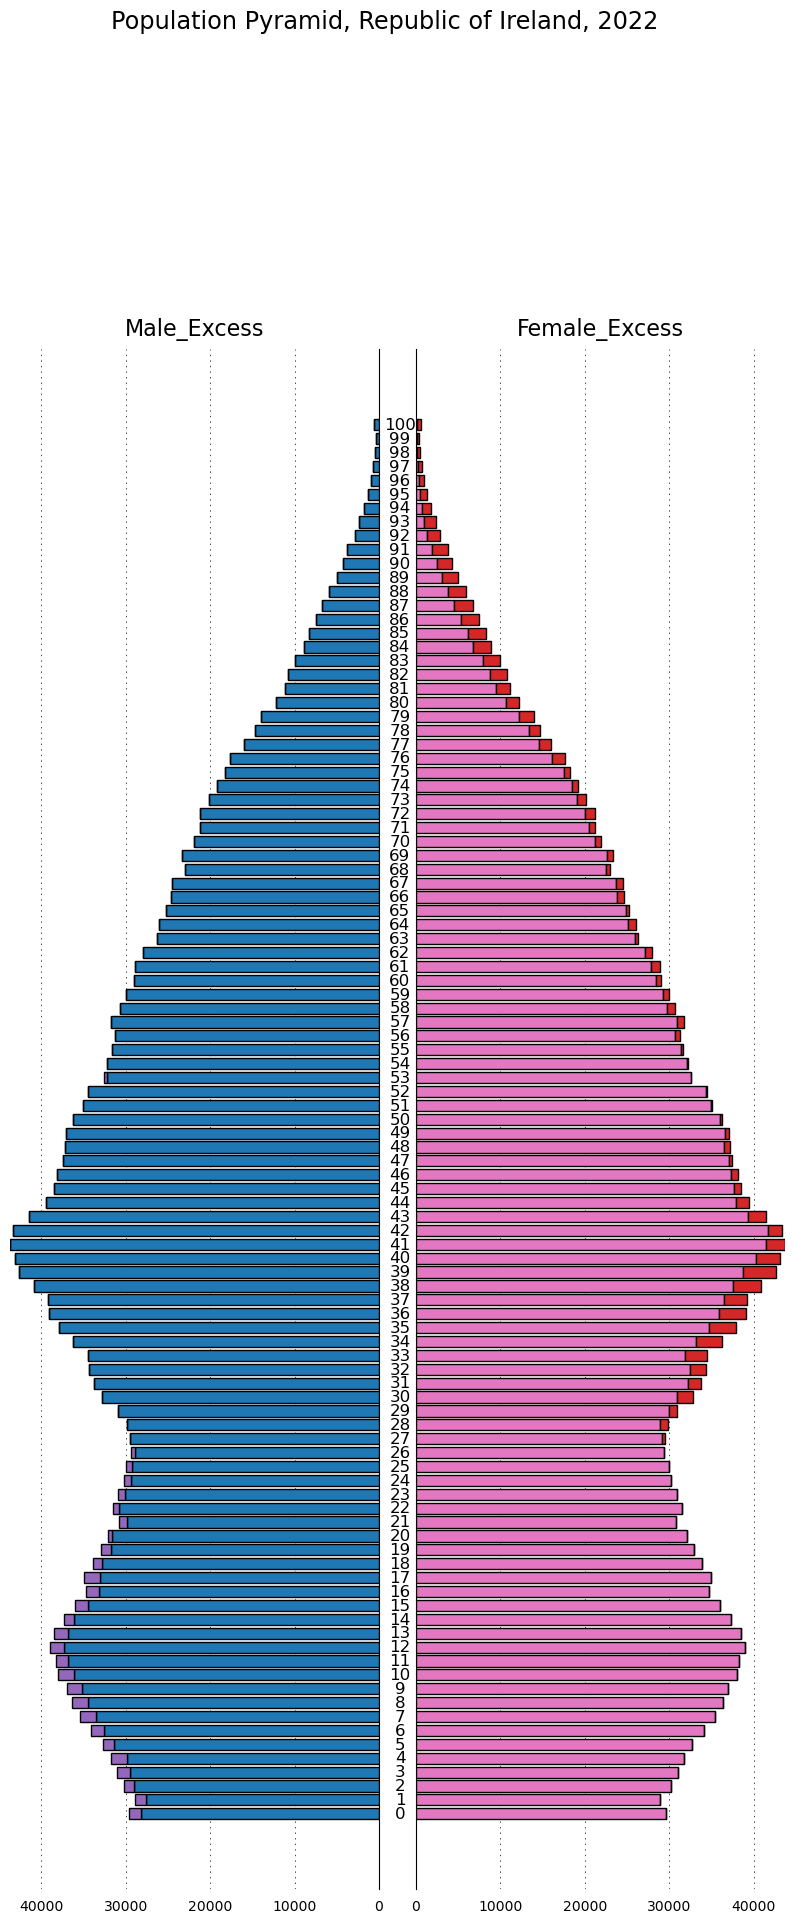

In [157]:
# For Calculating the sex gap at each age, i am going to implement the convention to subtract the number of males from the number of females. 
# This could have been done in either direction to get the difference, but as the gap changes from there being more males at younger ages 
# (due to a slightly higher proportion of births being male) to more females at older ages (Survivorship to old age is higher for females), 
# it is important to keep track of not only the magnitude of the discrepancy, but also its orientation.

# This section of code will perform subtraction operation on the values, and create new columns in the dataframe with values only if there is a positive value for excess population sex (negative discrepancies will be ignored). 
df_anal['Male_Excess'] = df_anal['Male']-df_anal['Female']
df_anal['Female_Excess'] = df_anal['Female']-df_anal['Male']
df_anal.clip(lower=0,inplace=True)
print(df_anal)

## lets see if running the butterfly chart again will allow me to place excesses outside the stacked horizontal bars 

def butterfly_chart(
        data: pd.DataFrame, 
        title: str = None,
        middle_label_offset=0.0,
        figsize=(1,1),
        wspace=0.6
    ):

# this section contains formatting for making the graph to be a pyramid graph
    plt.rcParams.update({
        # general background colour
        'figure.facecolor': 'w',
        # font sizes
        'font.size': 12,
        'axes.titlesize': 16,
        'xtick.labelsize': 10,
        # force black border
        'patch.force_edgecolor': True,
        'patch.facecolor': 'black',
        # remove spines
        'axes.spines.bottom': False,
        'axes.spines.left': False,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.bottom': False,
        'xtick.top': False,
        'axes.titlepad': 10,
        # grid
        'axes.grid': True,
        'grid.color': 'k',
        'grid.linestyle': ':',
        'grid.linewidth': 0.5,
        'lines.dotted_pattern': [1, 3],
        'lines.scale_dashes': False
    })

    fig, (ax1, ax2) = plt.subplots(
        figsize=figsize,
        dpi=100,
        nrows=1,
        ncols=2,
        subplot_kw={'yticks': []},
        gridspec_kw={'wspace': wspace},
    )
    
    
    # plot the data
    (l1, x1), (l2,x2), (l1, x4), (l2, x3) = data.items()
    y = range(len(x1))
    labels = data.index.tolist()

# I took the inspiration for the stacked horizontal bars from here: 
# https://stackoverflow.com/questions/16653815/horizontal-stacked-bar-chart-in-matplotlib
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.barh.html
# https://andrewpwheeler.com/2013/10/21/stacked-pyramid-bar-charts-for-likert-data/ i also found this chart type but it seems to be using a different programming language, possibly R.


    # Female Series control
    ax1.barh(y=y, width=x1, color='tab:blue', zorder=3) # this is the series for number of females by single year of age
    ax1.barh(y=y, width=x4, color='tab:purple', left = x1, zorder=3) # this is the series for number of excess qty of females at single year of age. I puit this outside the primary plot using the "left" module.
    ax2.set_title(l2)
    ax1.invert_xaxis()
    ax1.set_title(l1)

    # Male series control
    ax2.barh(y=y, width=x2, color='tab:pink', zorder=3) # this is the series for number of males by single year of age
    ax2.barh(y=y, width=x3, color='tab:red', left = x2, zorder=3) # this is the series for number of excess qty of males at single year of age. I puit this outside the primary plot using the "left" module.
    ax2.set_title(l2)

    
    # forced shared xlim
    x_max = max(ax1.get_xlim()[0], ax2.get_xlim()[0])
    ax1.set_xlim((x_max, 0))
    ax2.set_xlim((0, x_max))
    
    # turn on axes spines on the inside y-axis
    ax1.spines['right'].set_visible(True)
    ax2.spines['left'].set_visible(True)
    
    # format axes
    xfmt = mtick.ScalarFormatter()
    ax1.xaxis.set_major_formatter(xfmt)
    ax2.xaxis.set_major_formatter(xfmt)

    # place center labels
    transform = transforms.blended_transform_factory(fig.transFigure, ax1.transData)
    for i, label in enumerate(labels):
        ax1.text(0.5 + middle_label_offset, i, label, ha='center', va='center', transform=transform)

    plt.suptitle(title, y=1.05, fontsize='x-large')
    
    
butterfly_chart(
    df_anal,
    figsize=(10, 20),
    wspace=0.1,
    middle_label_offset=0.015,
    title='Population Pyramid, Republic of Ireland, 2022'
)


In [158]:
# this will give the result as a single column
# this satisfies the 2nd part in question 1 in assignmet 5: Age difference by sex. 
sex_gap_at_age = df_anal['Female']-df_anal['Male']
sex_gap_at_age

Single Year of Age
0     -1424
1     -1330
2     -1262
3     -1518
4     -1867
       ... 
96      629
97      515
98      362
99      231
100     430
Length: 101, dtype: int64

## Calculate what the cumulative ages are for each administrative district

In [159]:
cumages = df_anal[sex].mul(df_anal.index, axis = 0).sum()
cumages

101422203

In [160]:
# Assignment requirement - Weighted Mean
weighted_mean = cumages/number_people
weighted_mean

38.9397958987787

Weighted Median

In [161]:
cumsum = df_anal[sex].cumsum()
cumsum

Single Year of Age
0        28186
1        55731
2        84705
3       114188
4       144007
        ...   
96     2602446
97     2603178
98     2603670
99     2604006
100    2604590
Name: Female, Length: 101, dtype: int64

In [162]:
cutoff = df_anal[sex].sum()/2
cutoff

1302295.0

In [163]:
df_anal[sex][cumsum>=cutoff].index[0]

39

Weighted Standard Deviation

In [164]:
import numpy as np 
w_mean = np.average(df_anal.index, weights = df_anal[sex])
print("Weighted mean: ",w_mean)

Weighted mean:  38.9397958987787


In [165]:
w_variance = np.average((df_anal.index - w_mean)**2, weights = df_anal[sex])
print("Weighted Variance: ",w_variance)

Weighted Variance:  528.953520736661


In [166]:
w_std = np.sqrt(w_variance)
print("Weighted Standard Deviation: ", w_std)

Weighted Standard Deviation:  22.998989559036303


## End of code. 
Complete 12 Dec 2025